In [1]:
# %%
# %%
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from transformers import AutoModel

# 1. DINOv3 backbone id (gated repo -- accept the license on the HF model page and run
#    `huggingface-cli login` / set HF_TOKEN once, or from_pretrained() will 401).
#    ViT-S/16 -> hidden_size 384, matches the old VARIANT="small".
DINOV3_MODEL_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

# 2. Paths to your generated spectrogram dataset
DATA_ROOT = Path("spectrogram_dataset")  # Adjust this path to where your dataset is located
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

# 3. Hyperparameters
BATCH_SIZE = 32
HEAD_WARMUP_EPOCHS = 5      # phase 1: train only the head, backbone still frozen
FINETUNE_EPOCHS = 30        # phase 2: unfreeze backbone, fine-tune end-to-end
HEAD_LR = 1e-3              # LR for the classifier head (both phases)
BACKBONE_LR = 2e-5          # LR for the backbone during phase 2 -- must be much lower
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LABEL_SMOOTHING = 0.1
GRAD_CLIP_NORM = 1.0
UNFREEZE_LAST_N_BLOCKS = None  # None = unfreeze the whole backbone; set an int (e.g. 4)
                                # to only unfreeze the last N transformer blocks if you
                                # have a small dataset and full fine-tuning overfits.

print(f"Using device: {DEVICE}")

# %%
# 1. Find ALL unique classes across train, val, and test to ensure consistent label mapping
ALL_CLASSES = set()
for split in ['train', 'val', 'test']:
    split_dir = DATA_ROOT / split
    if split_dir.exists():
        for d in split_dir.iterdir():
            if d.is_dir():
                ALL_CLASSES.add(d.name)
ALL_CLASSES = sorted(list(ALL_CLASSES))
print(f"Total unique classes found across all splits: {len(ALL_CLASSES)}")


class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.samples = []

        for cls_name in self.classes:
            cls_dir = self.root_dir / cls_name
            if not cls_dir.exists():
                continue

            # Collect all images directly inside the class folder
            for img_path in cls_dir.glob("*"):
                if img_path.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}:
                    self.samples.append(
                        (str(img_path), self.class_to_idx[cls_name])
                    )

        print(f"{self.root_dir.name}: {len(self.samples)} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# Transforms -- DINOv3's LVD-1689M weights were trained with the standard ImageNet
# eval transform, same stats as before. 224x224 is a multiple of the ViT-S/16 patch
# size (16) -> 14x14 = 196 patch tokens (+1 CLS +4 register tokens internally).
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # RandomErasing operates on tensors, so it must come after ToTensor()/Normalize(),
    # not before -- a touch of masking helps a fine-tuned ViT generalize on small datasets.
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pass the global ALL_CLASSES list to the datasets
train_dataset = SpectrogramDataset(TRAIN_DIR, classes=ALL_CLASSES, transform=train_transform)
val_dataset = SpectrogramDataset(VAL_DIR, classes=ALL_CLASSES, transform=val_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


# %%
def _find_transformer_blocks(backbone):
    """HF vision backbones expose the transformer stack under different attribute
    paths depending on the exact model class. Try the common ones in order."""
    candidates = [
        ("encoder.layer", lambda m: m.encoder.layer),
        ("encoder.layers", lambda m: m.encoder.layers),
        ("layer", lambda m: m.layer),
        ("blocks", lambda m: m.blocks),
    ]
    for name, getter in candidates:
        try:
            blocks = getter(backbone)
            if blocks is not None and len(blocks) > 0:
                return name, blocks
        except AttributeError:
            continue
    raise AttributeError(
        "Could not locate the transformer block list on the DINOv3 backbone. "
        "Run `print(backbone)` to inspect the module structure and adjust "
        "_find_transformer_blocks() accordingly, or pass unfreeze_last_n_blocks=None "
        "to unfreeze the whole backbone without needing per-block access."
    )


def _find_final_norm(backbone):
    for name in ("layernorm", "norm", "layer_norm"):
        if hasattr(backbone, name):
            return getattr(backbone, name)
    return None


class DinoV3Classifier(nn.Module):
    def __init__(self, num_classes, model_id=DINOV3_MODEL_ID):
        super().__init__()
        # AutoModel.from_pretrained comes back with every parameter trainable by
        # default (unlike the old lingbot loader, which froze everything for you).
        # set_backbone_trainable() below explicitly controls this either way, so
        # behavior for phase 1 / phase 2 stays identical to before.
        self.backbone = AutoModel.from_pretrained(model_id)
        self.embed_dim = self.backbone.config.hidden_size

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.embed_dim),
            nn.Dropout(0.2),
            nn.Linear(self.embed_dim, num_classes)
        )

    def forward(self, x):
        outputs = self.backbone(pixel_values=x)
        # Prefer the pooler output if the model exposes one; otherwise fall back to
        # the CLS token (index 0 of the sequence) from the last hidden state.
        pooled = getattr(outputs, "pooler_output", None)
        if pooled is None:
            pooled = outputs.last_hidden_state[:, 0]
        logits = self.classifier(pooled)
        return logits

    def set_backbone_trainable(self, trainable: bool, unfreeze_last_n_blocks=None):
        """Explicitly control which backbone params get gradients.

        trainable=False -> everything frozen (linear-probe phase).
        trainable=True, unfreeze_last_n_blocks=None -> unfreeze the whole backbone.
        trainable=True, unfreeze_last_n_blocks=N -> only unfreeze the last N
            transformer blocks (cheaper, less prone to overfitting on small data).
        """
        for p in self.backbone.parameters():
            p.requires_grad_(False)

        if not trainable:
            self.backbone.eval()
            return

        if unfreeze_last_n_blocks is None:
            for p in self.backbone.parameters():
                p.requires_grad_(True)
        else:
            _, blocks = _find_transformer_blocks(self.backbone)
            blocks_to_unfreeze = blocks[-unfreeze_last_n_blocks:]
            for block in blocks_to_unfreeze:
                for p in block.parameters():
                    p.requires_grad_(True)
            # Also unfreeze the final norm, since it directly feeds the pooled feature
            final_norm = _find_final_norm(self.backbone)
            if final_norm is not None:
                for p in final_norm.parameters():
                    p.requires_grad_(True)

        self.backbone.train()


# %%
# 1. Count how many images belong to each class in the training set
class_counts = Counter([label for _, label in train_dataset.samples])
num_classes = len(ALL_CLASSES)

# 2. Calculate inverse frequency weights
weights = [1.0 / class_counts.get(i, 1) for i in range(num_classes)]

# 3. Normalize weights
weights = [w * num_classes / sum(weights) for w in weights]

# 4. Convert to tensor and move to GPU
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print(f"Applied class weights for {num_classes} classes. (Rare diseases now have higher priority)")

# Initialize model. set_backbone_trainable(False) puts us in the correct
# starting point for phase 1 (head warmup).
model = DinoV3Classifier(num_classes=num_classes).to(DEVICE)
model.set_backbone_trainable(False)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)


def make_optimizer(model, backbone_trainable):
    """Discriminative learning rates: head always trains faster than the backbone."""
    param_groups = [{"params": model.classifier.parameters(), "lr": HEAD_LR}]
    if backbone_trainable:
        trainable_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
        if trainable_backbone_params:
            param_groups.append({"params": trainable_backbone_params, "lr": BACKBONE_LR})
    return optim.AdamW(param_groups, weight_decay=1e-4)


def run_epoch(model, loader, criterion, optimizer=None, desc="Train"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    # Even in "train mode" for phase 1, keep frozen backbone submodules truly in eval
    # so their (batchnorm-like) layers don't drift; harmless once the backbone is unfrozen.

    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=desc)
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(
                    [p for g in optimizer.param_groups for p in g["params"]], GRAD_CLIP_NORM
                )
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f"{total_loss/total:.4f}", 'acc': f"{100.*correct/total:.2f}%"})

    return total_loss / total, 100. * correct / total


# %%
# ---------------- PHASE 1: head warmup (backbone frozen) ----------------
print("\n===== Phase 1: warming up the classifier head (backbone frozen) =====\n")
optimizer = make_optimizer(model, backbone_trainable=False)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HEAD_WARMUP_EPOCHS)

best_val_acc = 0.0
for epoch in range(HEAD_WARMUP_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, desc=f"Epoch {epoch+1}/{HEAD_WARMUP_EPOCHS} [Head Train]")
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, desc=f"Epoch {epoch+1}/{HEAD_WARMUP_EPOCHS} [Val]")
    scheduler.step()
    print(f"Epoch {epoch+1} Summary: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%\n")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_dinov3_svd.pth")
        print(f"--> Saved new best model with Val Acc: {val_acc:.2f}%\n")

# %%
# ---------------- PHASE 2: full fine-tuning (backbone unfrozen) ----------------
print("\n===== Phase 2: fine-tuning with backbone unfrozen =====\n")
model.set_backbone_trainable(True, unfreeze_last_n_blocks=UNFREEZE_LAST_N_BLOCKS)
optimizer = make_optimizer(model, backbone_trainable=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)

patience, patience_counter = 7, 0
for epoch in range(FINETUNE_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS} [FT Train]")
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS} [Val]")
    scheduler.step()
    print(f"Epoch {epoch+1} Summary: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%\n")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_dinov3_svd.pth")
        print(f"--> Saved new best model with Val Acc: {val_acc:.2f}%\n")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping: no val improvement for {patience} epochs.")
            break

# %%
# Load the best model weights

# %%

# %%

model.load_state_dict(torch.load("best_dinov3_svd.pth"))
model.eval()

# Setup test dataloader -- must pass classes=ALL_CLASSES, same as train/val,
# or the label indices won't match and accuracy will be meaningless / it will crash.
test_dataset = SpectrogramDataset(TEST_DIR, classes=ALL_CLASSES, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

test_correct = 0
test_total = 0

print("Evaluating on Test Set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\n🎉 Final Test Accuracy: {100. * test_correct / test_total:.2f}%")


# %%

Using device: cuda
Total unique classes found across all splits: 4
train: 1006 images
val: 217 images
Training samples: 1006
Validation samples: 217
Applied class weights for 4 classes. (Rare diseases now have higher priority)


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]


===== Phase 1: warming up the classifier head (backbone frozen) =====



Epoch 1/5 [Val]: 100%|██████████| 7/7 [00:01<00:00,  3.51it/s, loss=0.9546, acc=71.43%]


...

Epoch 16 Summary: Train Acc: 99.80% | Val Acc: 82.95%



Epoch 17/30 [Val]: 100%|██████████| 7/7 [00:01<00:00,  6.86it/s, loss=0.7593, acc=83.41%]


Epoch 17 Summary: Train Acc: 99.70% | Val Acc: 83.41%

Early stopping: no val improvement for 7 epochs.
test: 218 images
Evaluating on Test Set...


Testing: 100%|██████████| 7/7 [00:00<00:00,  7.20it/s]


🎉 Final Test Accuracy: 80.73%


Running inference...


100%|██████████| 7/7 [00:00<00:00,  7.91it/s]



Overall Accuracy : 80.73%
              precision    recall  f1-score   support

  Laryngitis     0.7188    0.7188    0.7188        64
 Vox senilis     0.8824    0.7627    0.8182        59
       dysar     0.5278    0.6552    0.5846        29
   parkinson     0.9851    1.0000    0.9925        66

    accuracy                         0.8073       218
   macro avg     0.7785    0.7842    0.7785       218
weighted avg     0.8183    0.8073    0.8107       218



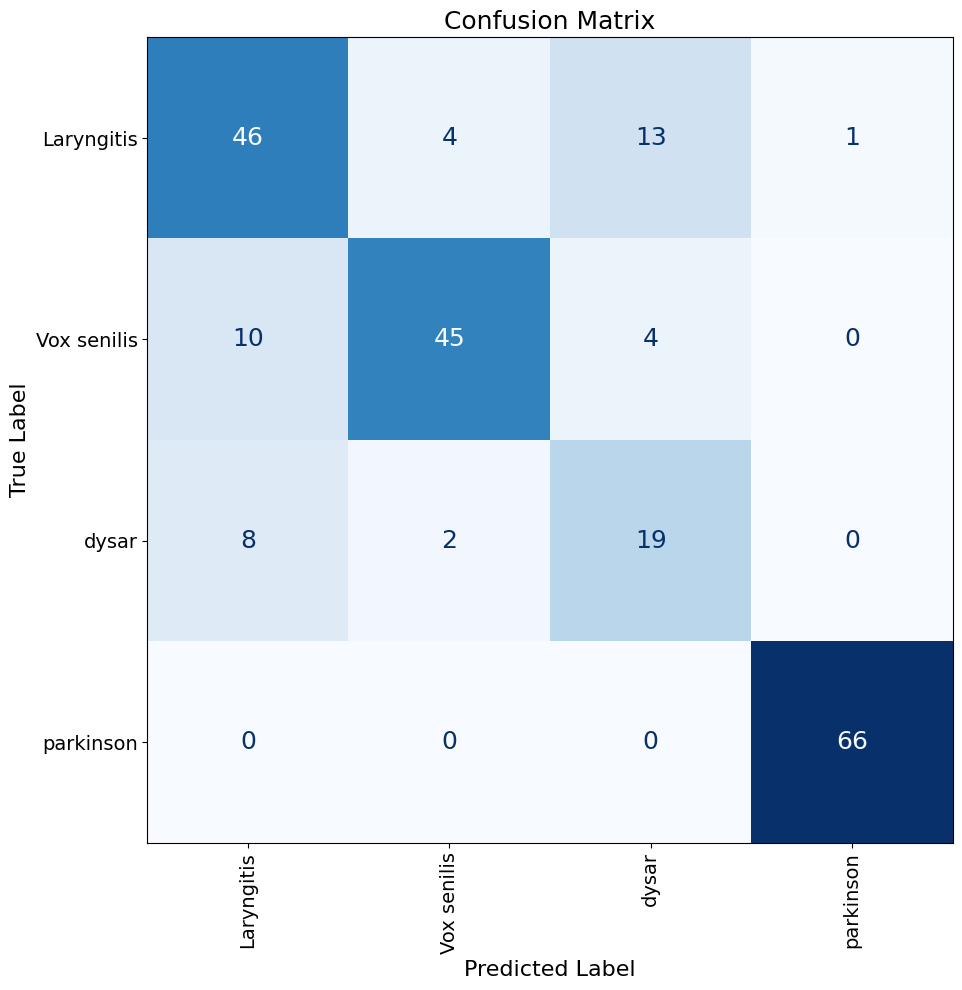

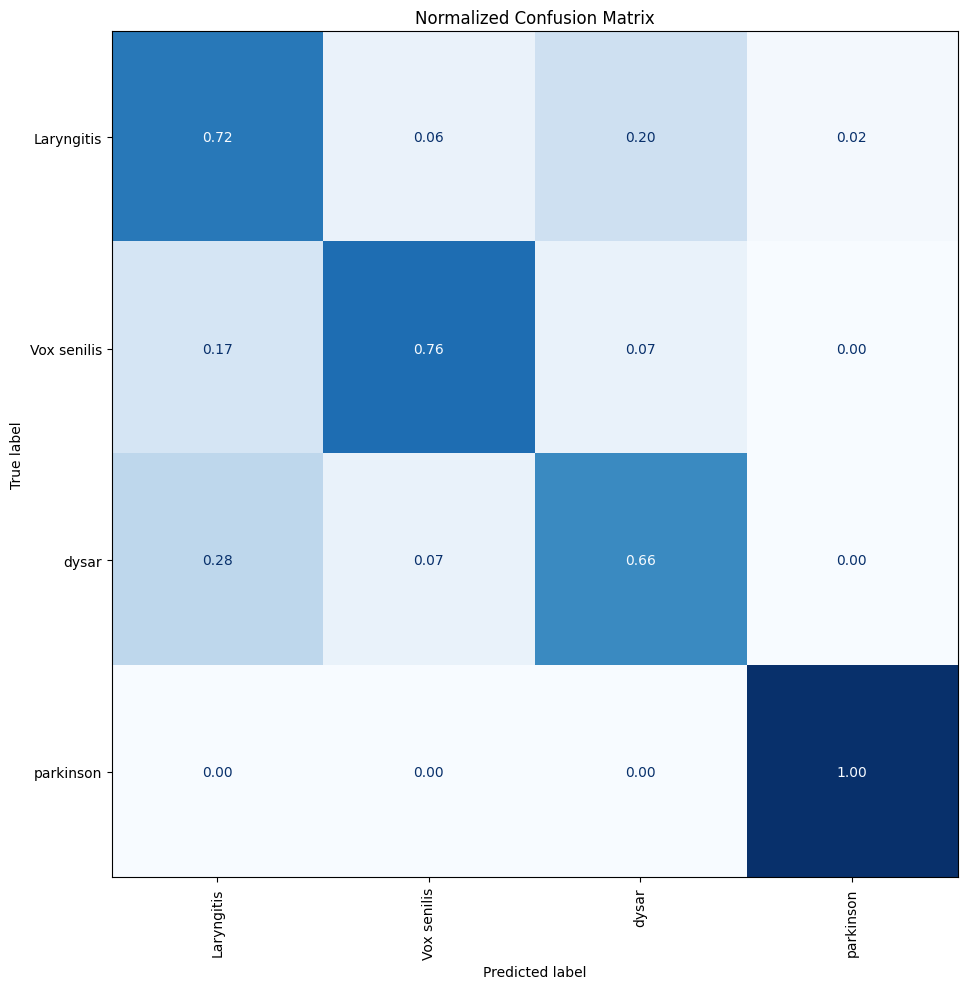


Per-Class Metrics

Laryngitis               P=0.719  R=0.719  F1=0.719  N=64
Vox senilis              P=0.882  R=0.763  F1=0.818  N=59
dysar                    P=0.528  R=0.655  F1=0.585  N=29
parkinson                P=0.985  R=1.000  F1=0.992  N=66


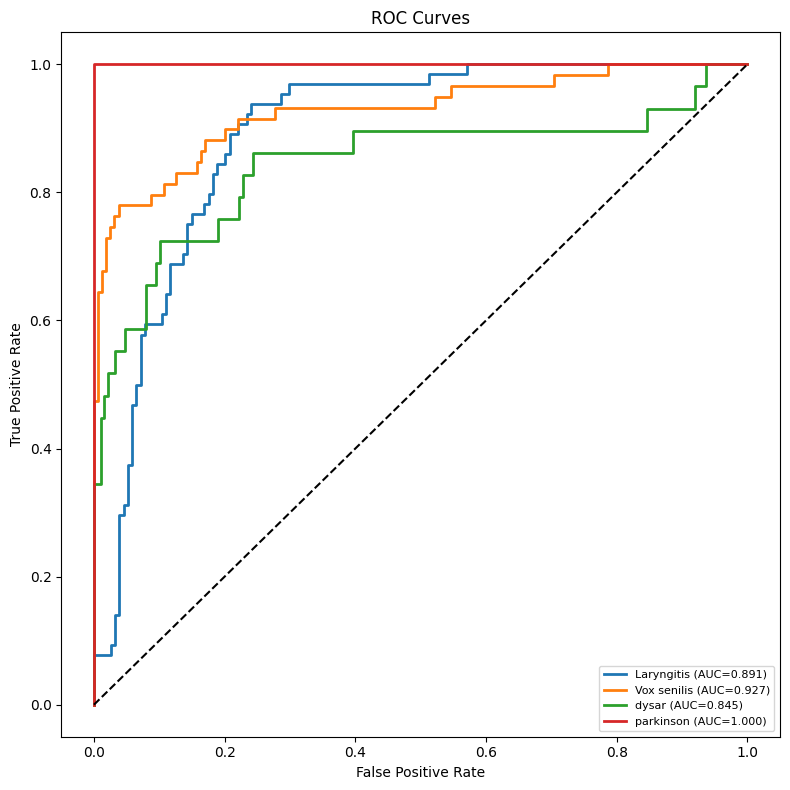

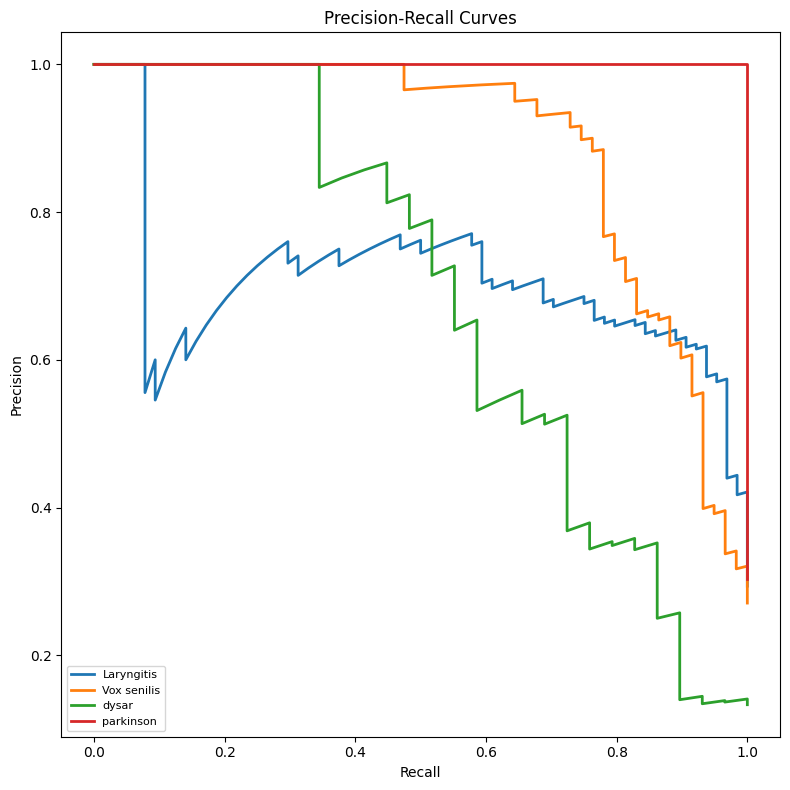


All evaluation results saved to 'evaluation_results'


In [3]:
# ============================================
# Complete Evaluation on Test Set
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# Load best checkpoint
model.load_state_dict(torch.load("best_dinov3_svd.pth", map_location=DEVICE))
model.eval()

SAVE_DIR = "evaluation_results"
os.makedirs(SAVE_DIR, exist_ok=True)

y_true = []
y_pred = []
y_prob = []

print("Running inference...")

with torch.no_grad():
    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = probs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ==================================================
# Accuracy
# ==================================================

acc = accuracy_score(y_true, y_pred)

print(f"\nOverall Accuracy : {acc*100:.2f}%")

# ==================================================
# Classification Report
# ==================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=ALL_CLASSES,
    digits=4
)

print(report)

with open(os.path.join(SAVE_DIR,"classification_report.txt"),"w") as f:
    f.write(report)

# ==================================================
# Confusion Matrix
# ==================================================

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ALL_CLASSES
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    ax=ax,
    colorbar=False
)

# Increase the size of the numbers inside the cells
for text in disp.text_.ravel():
    text.set_fontsize(18)   # Change to desired size

plt.title("Confusion Matrix", fontsize=18)
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)

# Increase tick label size
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=800)
plt.show()
# ==================================================
# Normalized Confusion Matrix
# ==================================================

cm_norm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(10,10))

ConfusionMatrixDisplay(
    cm_norm,
    display_labels=ALL_CLASSES
).plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format=".2f",
    colorbar=False,
    ax=ax
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"normalized_confusion_matrix.png"),dpi=300)
plt.show()

# ==================================================
# Precision Recall F1
# ==================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred
)

print("\nPer-Class Metrics\n")

for i, cls in enumerate(ALL_CLASSES):
    print(
        f"{cls:25s}"
        f"P={precision[i]:.3f}  "
        f"R={recall[i]:.3f}  "
        f"F1={f1[i]:.3f}  "
        f"N={support[i]}"
    )

# ==================================================
# ROC Curves
# ==================================================

num_classes = len(ALL_CLASSES)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(num_classes)
)

plt.figure(figsize=(8,8))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{ALL_CLASSES[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"roc_curves.png"),dpi=800)
plt.show()

# ==================================================
# Precision-Recall Curves
# ==================================================

plt.figure(figsize=(8,8))

for i in range(num_classes):

    p,r,_ = precision_recall_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    plt.plot(
        r,
        p,
        lw=2,
        label=ALL_CLASSES[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,"precision_recall_curves.png"),dpi=800)
plt.show()

print(f"\nAll evaluation results saved to '{SAVE_DIR}'")